# 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Estilo visual consistente en todas las gráficas.
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_PATH = "../outputs/figures/"

# 2. Carga y primer vistazo

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nNulos por columna:\n{df.isnull().sum()}")
print(f"\nTipos de datos:\n{df.dtypes}")
df.head(3)

Shape: (114000, 21)

Columnas: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Nulos por columna:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Tipos de datos:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms  

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


# 3. Limpieza básica


In [3]:
# Eliminar duplicados y nulos
df = df.drop_duplicates()
df = df.dropna()

# Normalizamos la columna 'track_genre' que puede tener espacios.
df['track_genre'] = df['track_genre'].str.strip().str.lower()

# Convertir 'explicit' a int si es booleano
df['explicit'] = df['explicit'].astype(int)

print(f"Shape después de limpieza: {df.shape}")


Shape después de limpieza: (113999, 21)


# 4. Top géneros por popularidad media

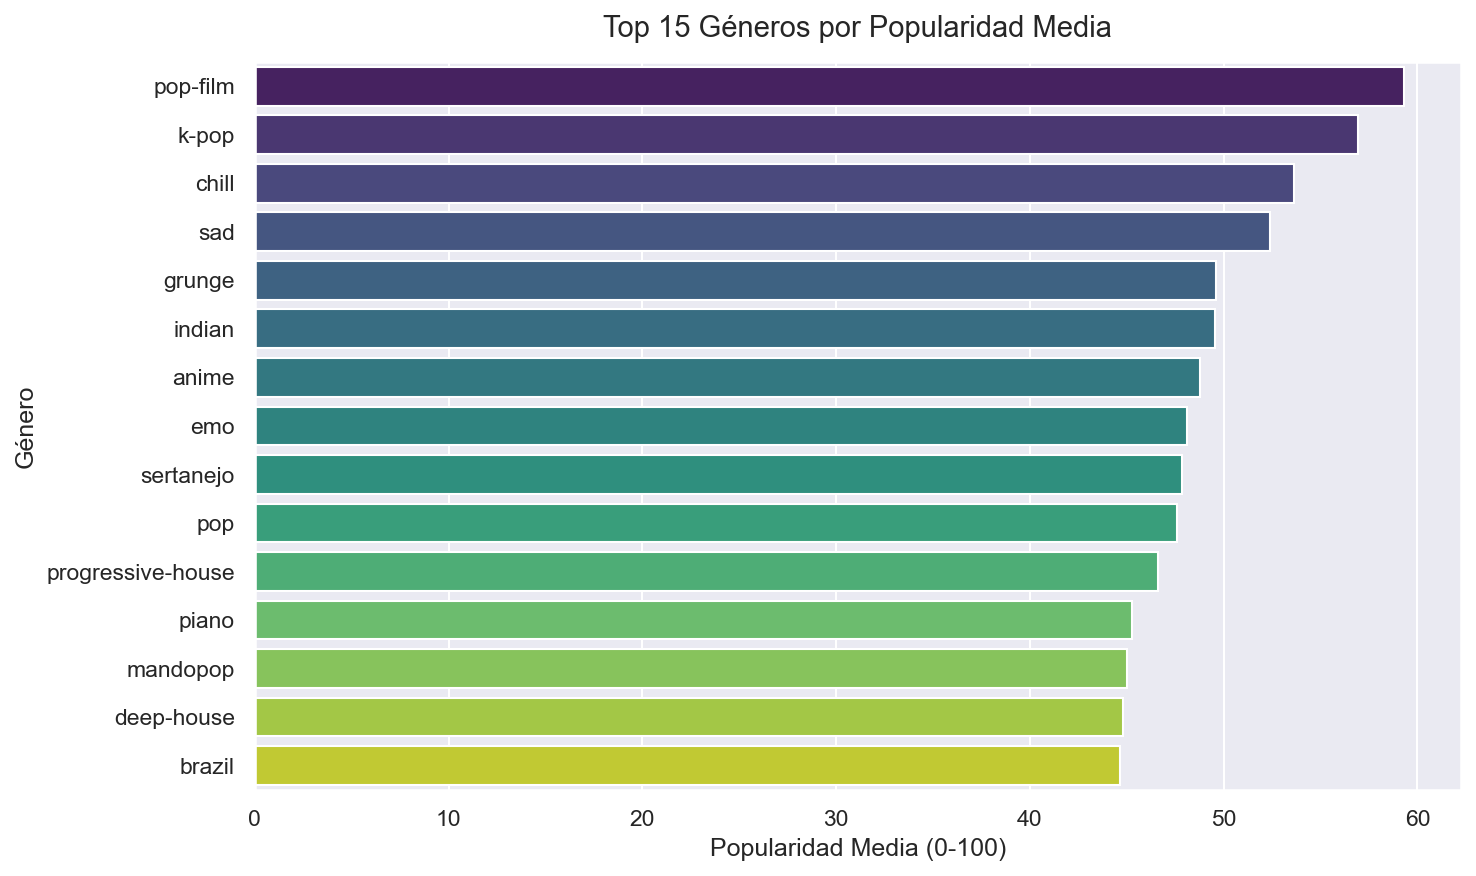

In [5]:
top_genres = (
    df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15).reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=top_genres, x='popularity', y='track_genre', palette='viridis', ax=ax)
ax.set_title("Top 15 Géneros por Popularidad Media", fontsize=14, pad=12)
ax.set_xlabel("Popularidad Media (0-100)")
ax.set_ylabel("Género")
plt.tight_layout()
plt.savefig(FIGURES_PATH + "top_genres_popularity.png")
plt.show()

# 5. Top artistas globales

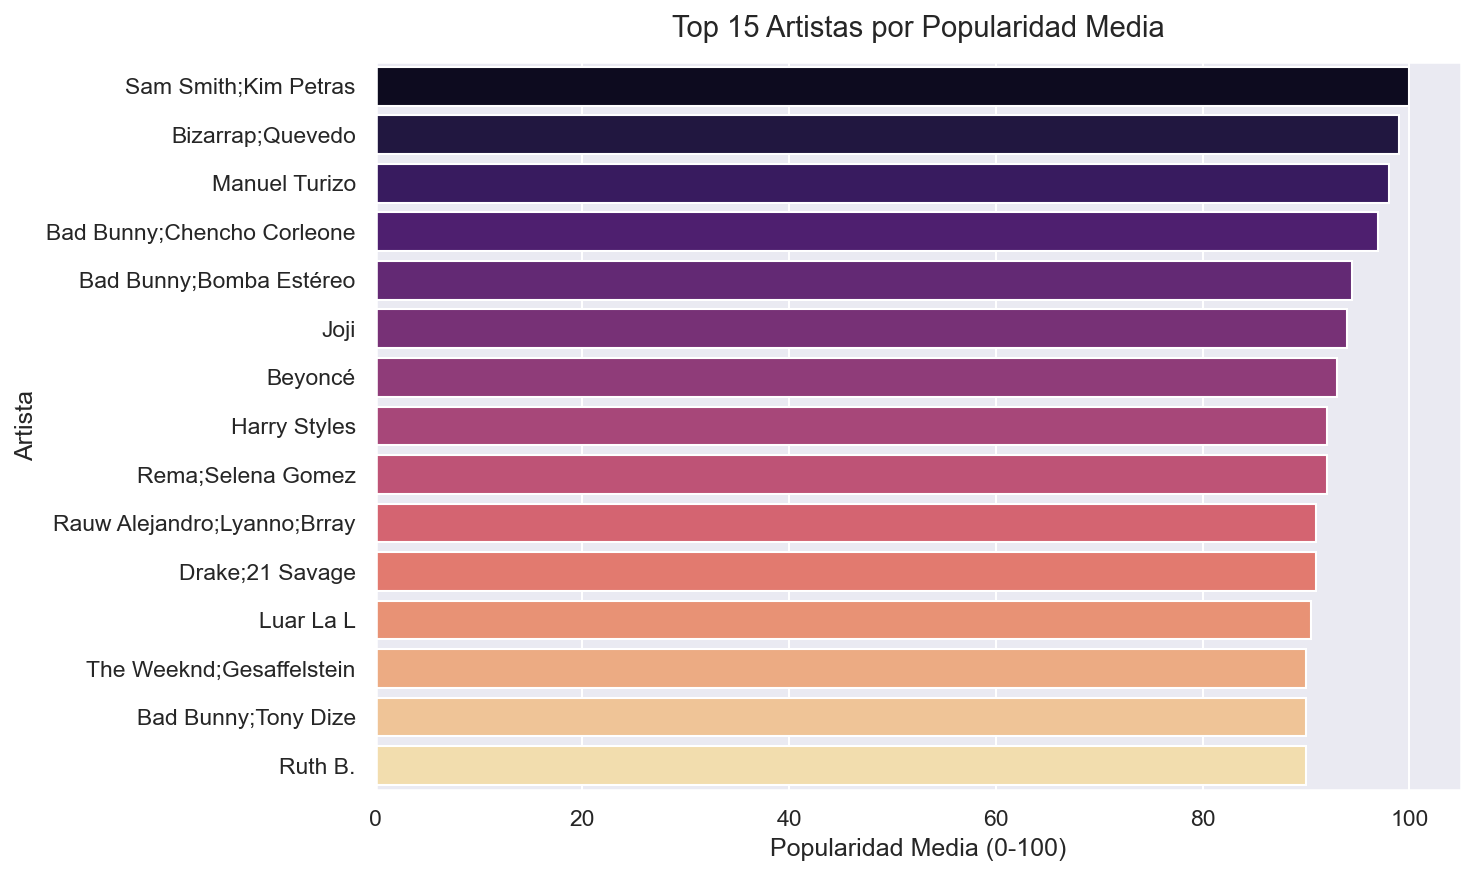

In [8]:
top_artists = (
    df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(15).reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=top_artists, x='popularity', y='artists', palette='magma', ax=ax)
ax.set_title('Top 15 Artistas por Popularidad Media', fontsize=14, pad=12)
ax.set_xlabel('Popularidad Media (0-100)')
ax.set_ylabel('Artista')
plt.tight_layout()
plt.savefig(FIGURES_PATH + "top_artists_popularity.png")
plt.show()

# 6. Distribución de popularidad

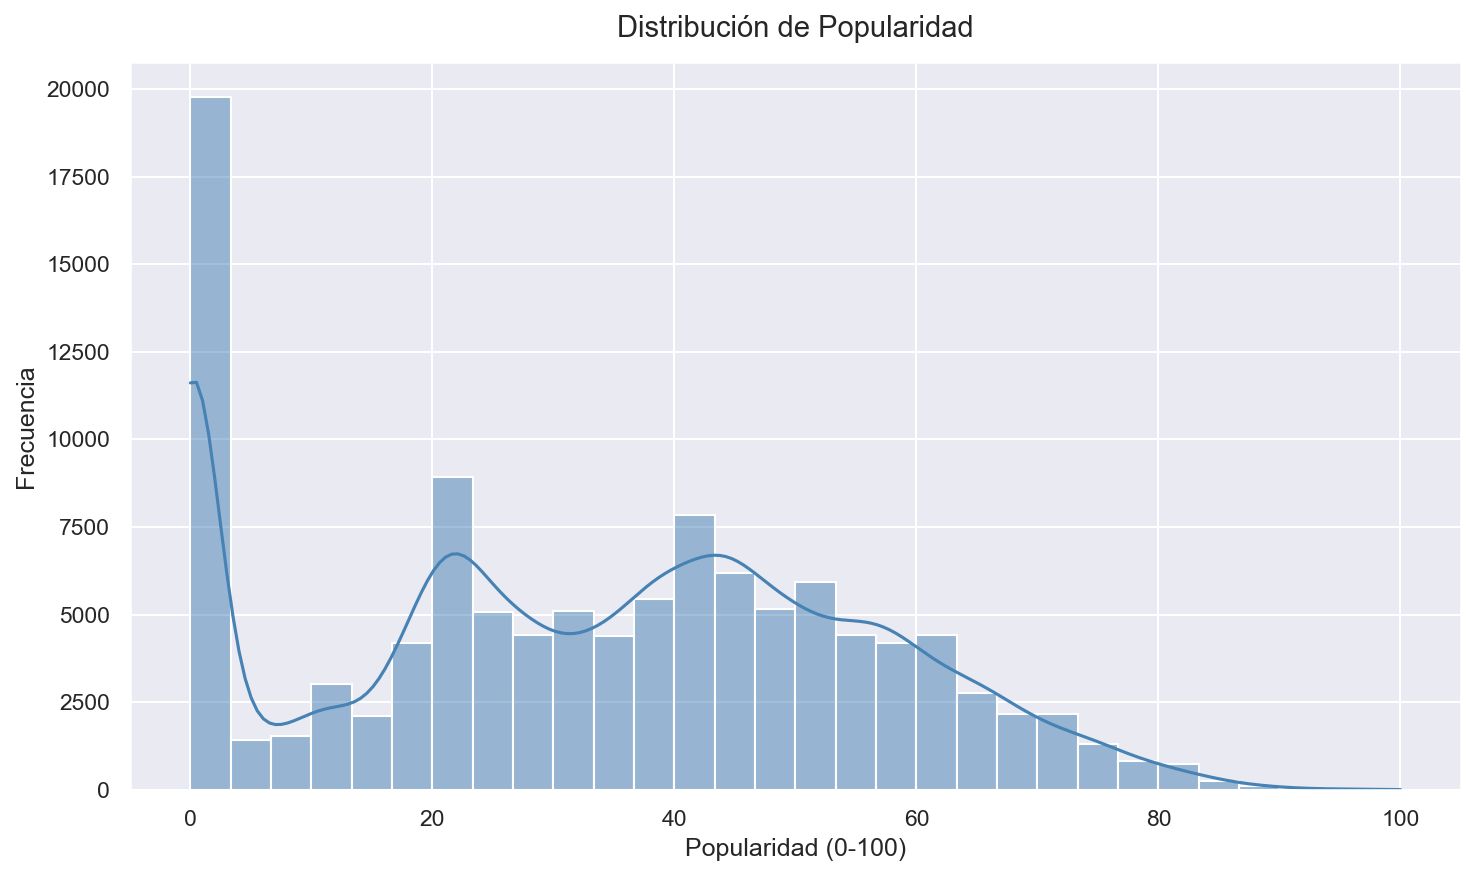

Media: 33.2
Mediana: 35.0
Canciones con popularidad 0: 16019


In [9]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(df['popularity'], bins=30, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribución de Popularidad', fontsize=14, pad=12)
ax.set_xlabel('Popularidad (0-100)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIGURES_PATH + "popularity_distribution.png")
plt.show()

# Es probable que haya muchas canciones con popularidad 0. Lo usaremos en el modelo para decidir si filtramos.

print(f"Media: {df['popularity'].mean():.1f}")
print(f"Mediana: {df['popularity'].median():.1f}")
print(f"Canciones con popularidad 0: {(df['popularity'] == 0).sum()}")


# 7. Correlación audio features vs popularidad

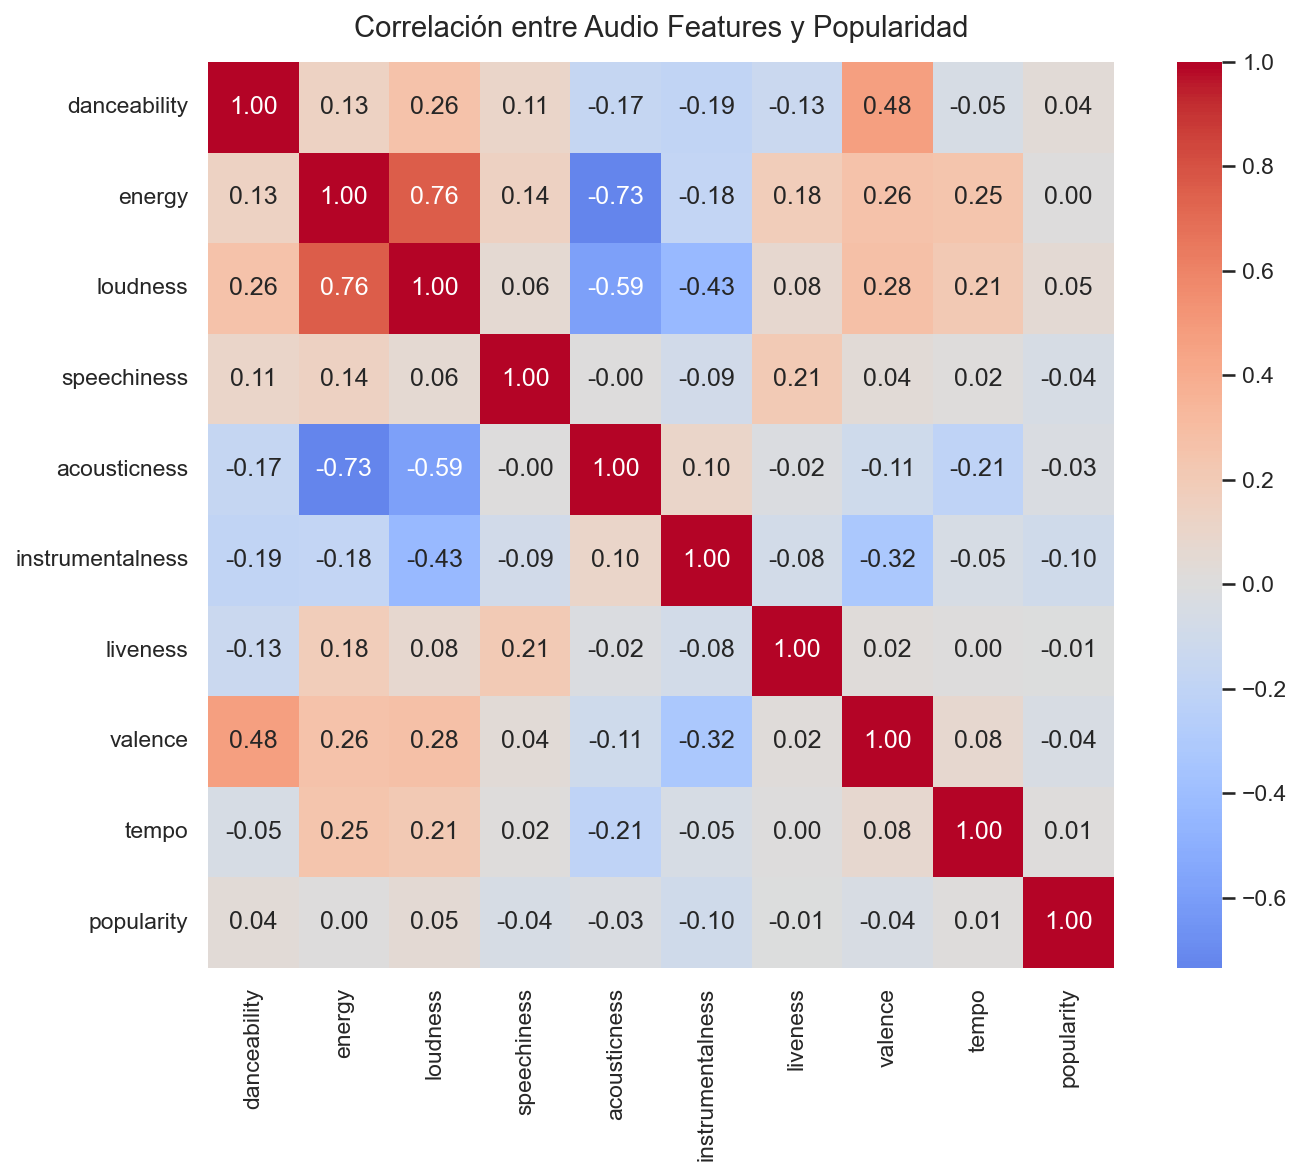

In [11]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity'
]

corr = df[audio_features].corr()

fig, ax= plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax, center=0, square=True)
ax.set_title('Correlación entre Audio Features y Popularidad', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}correlation_heatmap.png")
plt.show()

# 8. Energía vs popularidad por género (top 6)

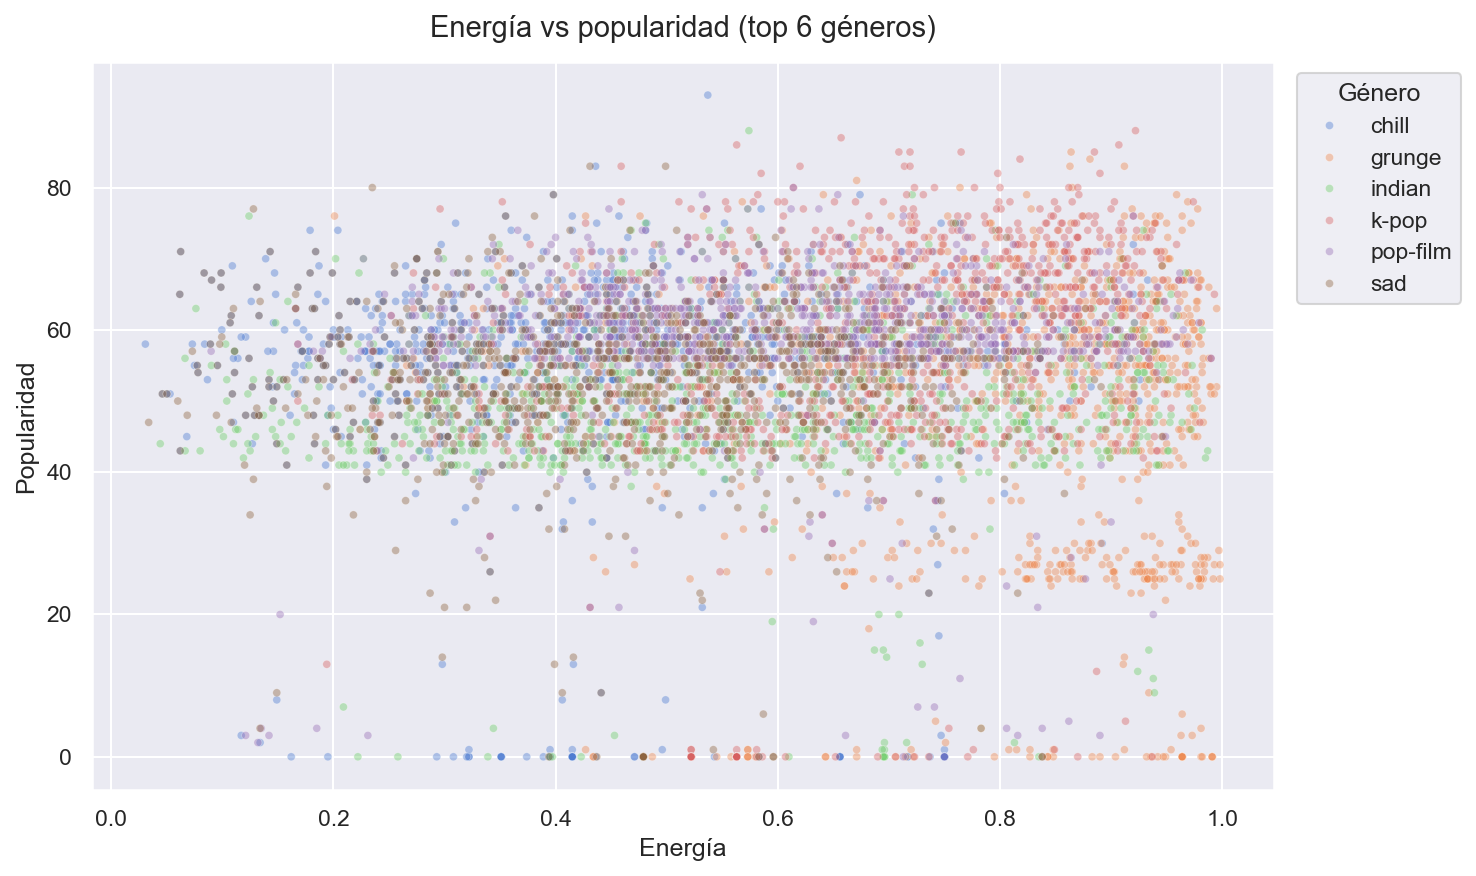

In [12]:
top6_genres = top_genres['track_genre'].head(6).tolist()
df_top6 = df[df['track_genre'].isin(top6_genres)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_top6, x='energy', y='popularity',
                hue='track_genre', alpha=0.4, s=15, ax=ax)
ax.set_title('Energía vs popularidad (top 6 géneros)', fontsize=14, pad=12)
ax.set_xlabel('Energía')
ax.set_ylabel('Popularidad')
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}energy_vs_popularity.png")
plt.show()

# 9. Danceability por género (Estilo Wrapped)

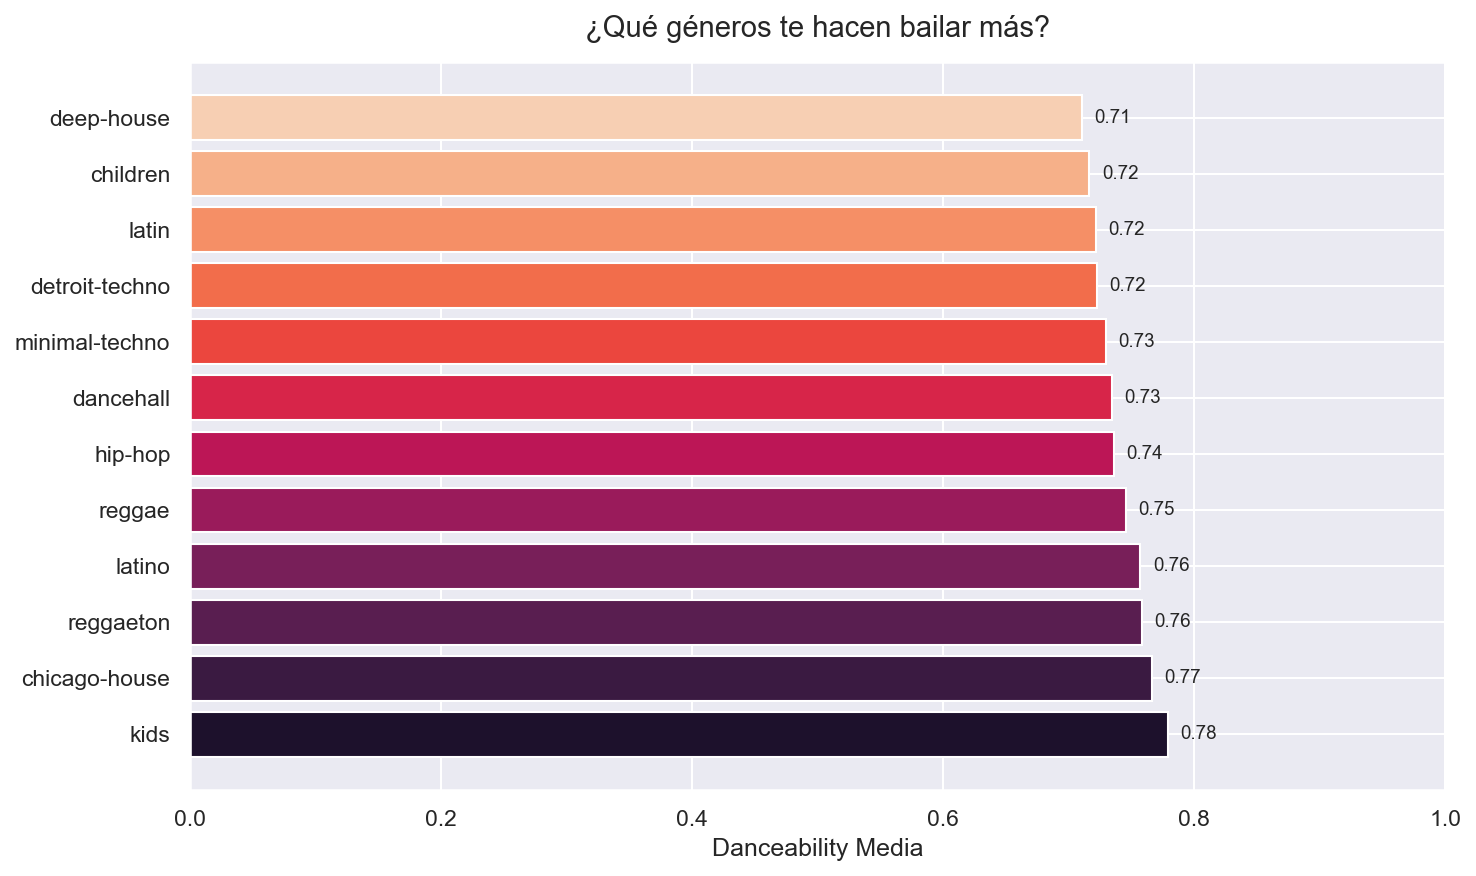

In [15]:
dance_genre = (
    df.groupby('track_genre')['danceability'].mean().sort_values(ascending=False).head(12).reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(dance_genre['track_genre'], dance_genre['danceability'], color=sns.color_palette('rocket', len(dance_genre)))

ax.set_title('¿Qué géneros te hacen bailar más?', fontsize=14, pad = 12)
ax.set_xlabel('Danceability Media')
ax.set_xlim(0, 1)
for bar, val in zip(bars, dance_genre['danceability']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}danceability_by_genre.png")
plt.show()

# 10. Resumen final del EDA

In [16]:
print("=" * 50)
print("RESUMEN EDA — Spotify Wrapped")
print("=" * 50)
print(f"Total canciones analizadas:  {len(df):,}")
print(f"Géneros únicos:              {df['track_genre'].nunique()}")
print(f"Artistas únicos:             {df['artists'].nunique():,}")
print(f"Popularidad media:           {df['popularity'].mean():.1f}/100")
print(f"Género más popular:          {top_genres.iloc[0]['track_genre']}")
print(f"Artista más popular:         {top_artists.iloc[0]['artists']}")
print(f"Feature más correlacionada:  {corr['popularity'].drop('popularity').abs().idxmax()}")
print("=" * 50)

RESUMEN EDA — Spotify Wrapped
Total canciones analizadas:  113,999
Géneros únicos:              114
Artistas únicos:             31,437
Popularidad media:           33.2/100
Género más popular:          pop-film
Artista más popular:         Sam Smith;Kim Petras
Feature más correlacionada:  instrumentalness


# 11. Conclusiones EDA

In [17]:

conclusiones = """
CONCLUSIONES EDA
================
1. Ningún audio feature tiene correlación lineal fuerte con popularidad (max: loudness +0.05)
2. La popularidad depende más del género y factores externos que del sonido
3. Alta multicolinealidad: energy-acousticness (-0.73), energy-loudness (+0.76)
4. Para el modelo: usar Random Forest + track_genre codificado
5. Filtrar canciones con popularity == 0 antes de entrenar
"""
print(conclusiones)

# Guardar features relevantes para el modelo
features_modelo = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'explicit', 'track_genre'
]
print(f"Features para el modelo: {features_modelo}")
print(f"Target: popularity")


CONCLUSIONES EDA
1. Ningún audio feature tiene correlación lineal fuerte con popularidad (max: loudness +0.05)
2. La popularidad depende más del género y factores externos que del sonido
3. Alta multicolinealidad: energy-acousticness (-0.73), energy-loudness (+0.76)
4. Para el modelo: usar Random Forest + track_genre codificado
5. Filtrar canciones con popularity == 0 antes de entrenar

Features para el modelo: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'explicit', 'track_genre']
Target: popularity
